<a href="https://colab.research.google.com/github/RaniaDK/Projet_ML/blob/main/Copie_de_projet_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# **1.2 Charger le dataset**

In [ ]:
df = pd.read_excel("/content/cancer_patient_dirty_pro.xlsx")
df.head()

,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,NaN,33.0,1.0,2.000000,4.0,15.058866,4.0,3.0,2.0,2.000000,...,NaN,4.0,2.0,2.0,3.0,1.0,NaN,3.0,4.0,Low
1,NaN,17.0,NaN,3.000000,1.0,5.000000,3.0,4.0,2.0,2.000000,...,1.0,3.0,7.0,NaN,6.0,2.0,1.0,NaN,2.0,Medium
2,P100,35.0,1.0,13.984879,5.0,6.000000,5.0,5.0,4.0,15.184317,...,8.0,7.0,9.0,NaN,1.0,4.0,6.0,7.0,2.0,High
3,NaN,37.0,NaN,7.000000,NaN,NaN,7.0,6.0,7.0,7.000000,...,4.0,NaN,3.0,1.0,4.0,5.0,6.0,7.0,5.0,High
4,NaN,46.0,1.0,6.000000,8.0,7.000000,NaN,7.0,6.0,15.184317,...,3.0,2.0,4.0,1.0,4.0,2.0,4.0,2.0,3.0,NaN


# **1.3 Dimensions du dataset**

In [ ]:
df.shape

(1100, 25)

# **1.4 Informations générales**

In [ ]:
print(df.isnull().sum())

Patient Id                  212
Age                         226
Gender                      201
Air Pollution               200
Alcohol use                 254
Dust Allergy                200
OccuPational Hazards        212
Genetic Risk                192
chronic Lung Disease        207
Balanced Diet               227
Obesity                     225
Smoking                     178
Passive Smoker              220
Chest Pain                  203
Coughing of Blood           209
Fatigue                     206
Weight Loss                 230
Shortness of Breath         241
Wheezing                    227
Swallowing Difficulty       211
Clubbing of Finger Nails    220
Frequent Cold               209
Dry Cough                   202
Snoring                     210
Level                       215
dtype: int64


# **1.5 Statistiques**

In [ ]:
df.describe()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring
count,874.000000,899.000000,900.000000,846.000000,900.000000,888.000000,908.000000,893.000000,873.000000,875.000000,...,891.000000,894.000000,870.000000,859.000000,873.000000,889.000000,880.000000,891.000000,898.000000,890.000000
mean,39.690931,1.567149,4.314867,5.275608,5.688564,5.382622,5.243152,4.972136,5.118321,5.077389,...,5.521920,4.479083,4.426722,4.828886,4.284400,4.264197,4.583596,4.115486,4.455278,3.435403
std,17.404345,0.785700,2.904560,3.969099,2.903070,3.006172,3.283296,2.832545,3.130970,3.234584,...,3.748326,3.492592,3.294668,3.275922,2.924734,3.245402,3.590323,2.784856,3.100091,2.306006
min,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,28.000000,1.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,37.000000,1.000000,4.000000,5.000000,6.000000,5.000000,5.000000,5.000000,6.000000,4.000000,...,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,45.750000,2.000000,6.000000,7.000000,7.000000,7.000000,7.000000,6.000000,7.000000,7.000000,...,7.000000,5.000000,7.000000,6.000000,6.000000,6.000000,5.000000,6.000000,6.000000,4.000000
max,97.282713,3.855036,13.984879,17.649259,15.058866,15.327819,15.286951,13.565776,15.184317,15.154303,...,16.754927,14.726239,14.760163,15.795202,14.058496,15.146780,15.664702,12.590705,14.015851,10.324708


# **1.6 Vérifier la target**

In [ ]:
df["Level"].value_counts()

,count
Level,
High,326
Medium,286
Low,273


# **ÉTAPE 2 : Analyse Exploratoire des Données (EDA)**

# **2.1 Distribution de la target**

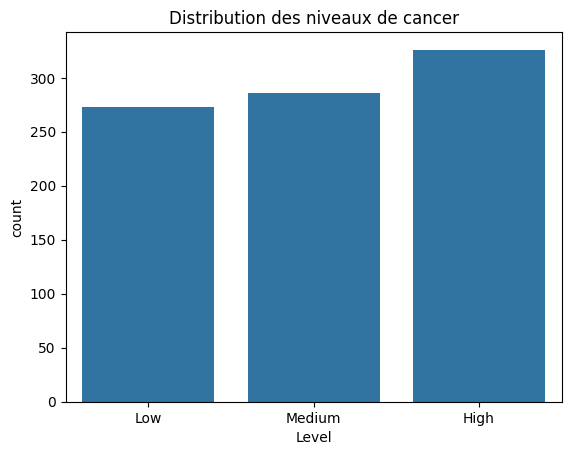

In [ ]:
sns.countplot(x="Level", data=df)
plt.title("Distribution des niveaux de cancer")
plt.show()

# **2.2 Histogrammes**

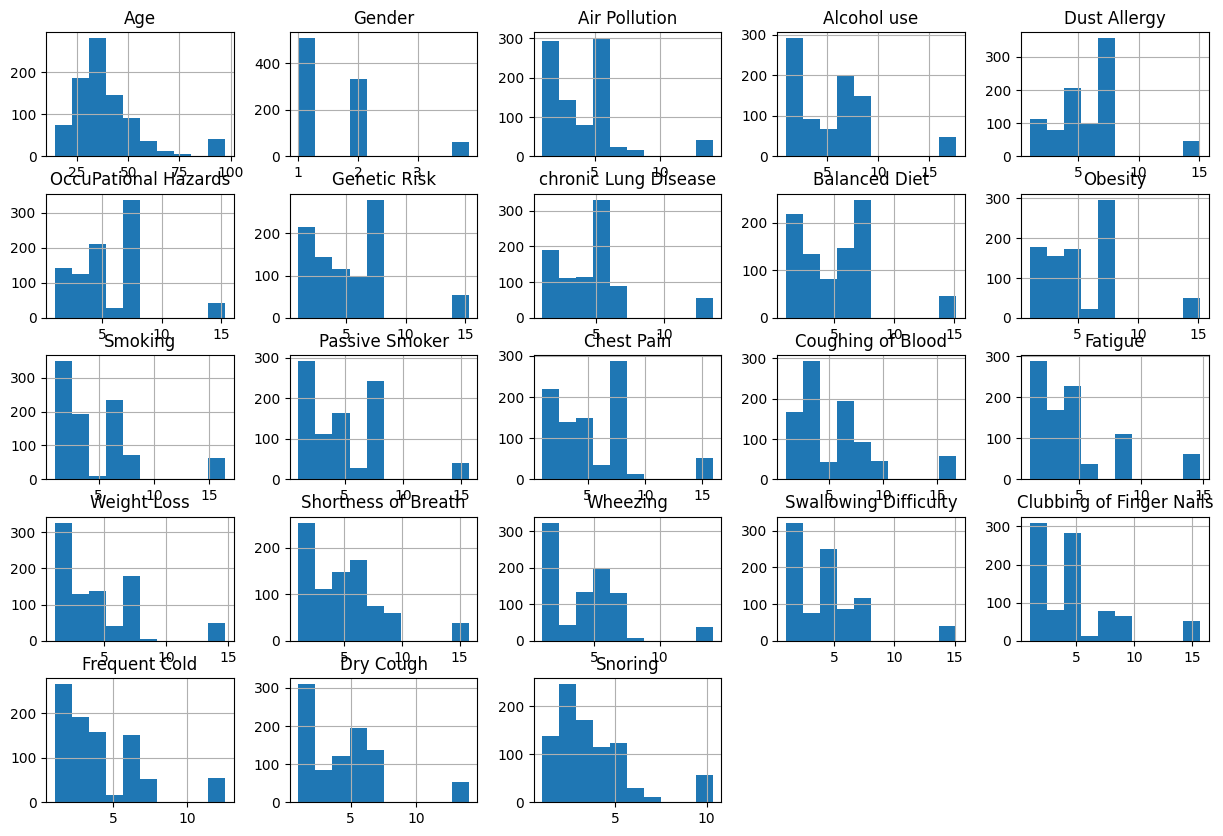

In [ ]:
df.hist(figsize=(15,10))
plt.show()

# **2.3 Corrélation entre variables**

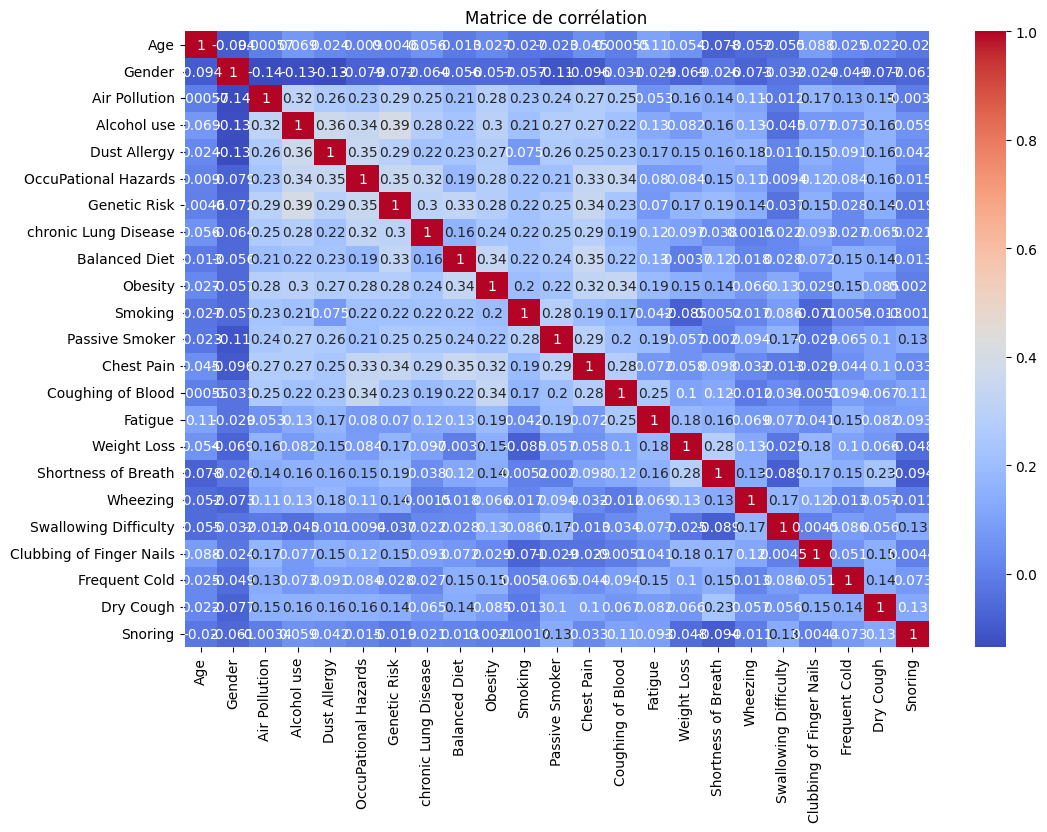

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

# **2.4 Boxplot **

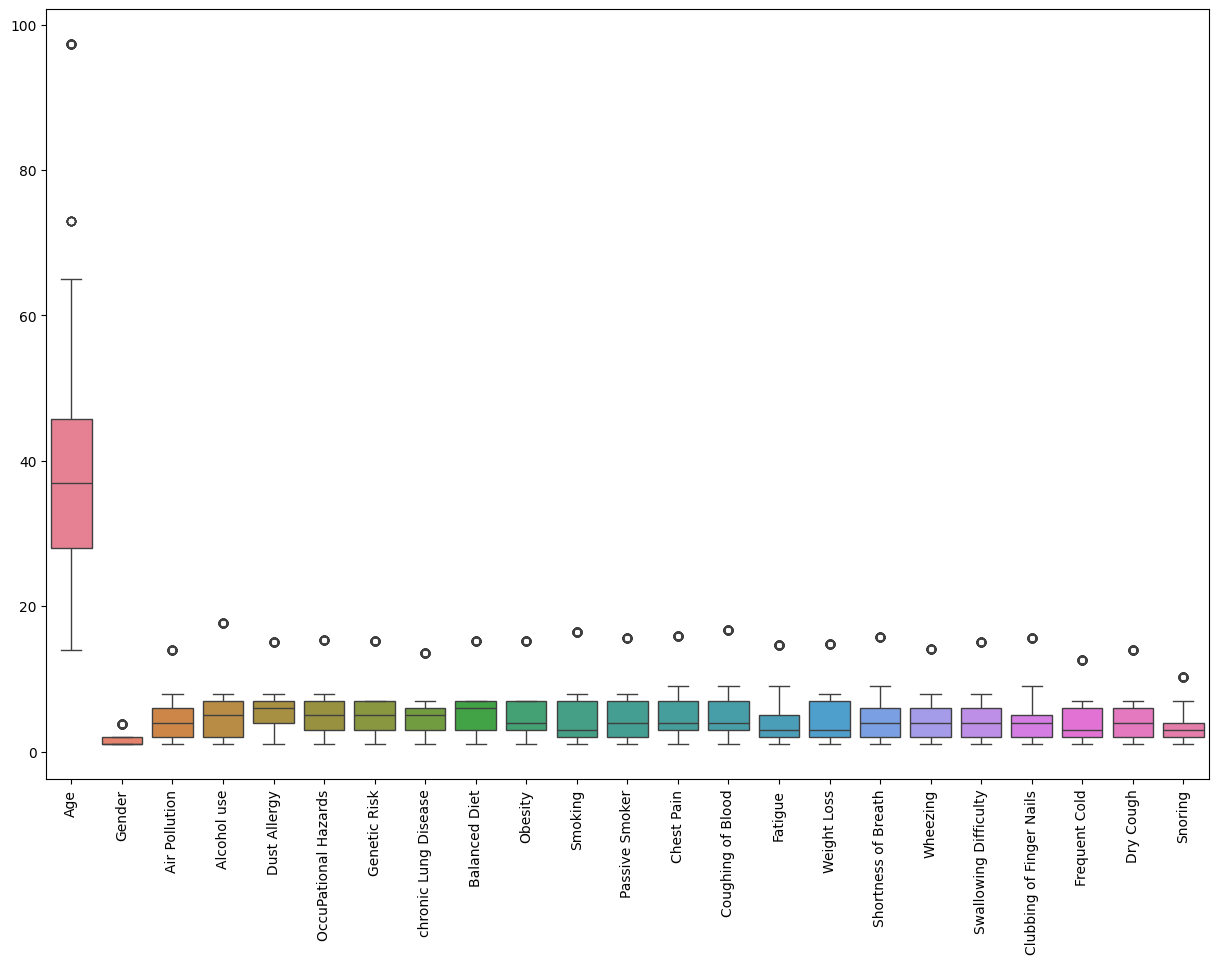

In [ ]:
plt.figure(figsize=(15,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# **ÉTAPE 3 :**

# **1- Traitement des Valeurs Manquantes**

In [ ]:
df = df.fillna(df.median(numeric_only=True))

le = LabelEncoder()
df['Level'] = le.fit_transform(df['Level'].astype(str))

print(df.isnull().sum())

Patient Id                  212
Age                           0
Gender                        0
Air Pollution                 0
Alcohol use                   0
Dust Allergy                  0
OccuPational Hazards          0
Genetic Risk                  0
chronic Lung Disease          0
Balanced Diet                 0
Obesity                       0
Smoking                       0
Passive Smoker                0
Chest Pain                    0
Coughing of Blood             0
Fatigue                       0
Weight Loss                   0
Shortness of Breath           0
Wheezing                      0
Swallowing Difficulty         0
Clubbing of Finger Nails      0
Frequent Cold                 0
Dry Cough                     0
Snoring                       0
Level                         0
dtype: int64


# **2- Suppression des Colonnes Inutiles**

In [ ]:
if 'Patient Id' in df.columns:
    df = df.drop('Patient Id', axis=1)

print(df.columns)

Index(['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring', 'Level'],
      dtype='object')


# **3- Correction des Outliers**

In [ ]:
cols_to_fix = ['Air Pollution', 'Alcohol use', 'Dust Allergy', 'Balanced Diet']

for col in cols_to_fix:
    df[col] = df[col].clip(upper=8)

print(df[cols_to_fix].describe().loc['max'])

Air Pollution    8.0
Alcohol use      8.0
Dust Allergy     8.0
Balanced Diet    8.0
Name: max, dtype: float64


# **4- Vérification Finale**

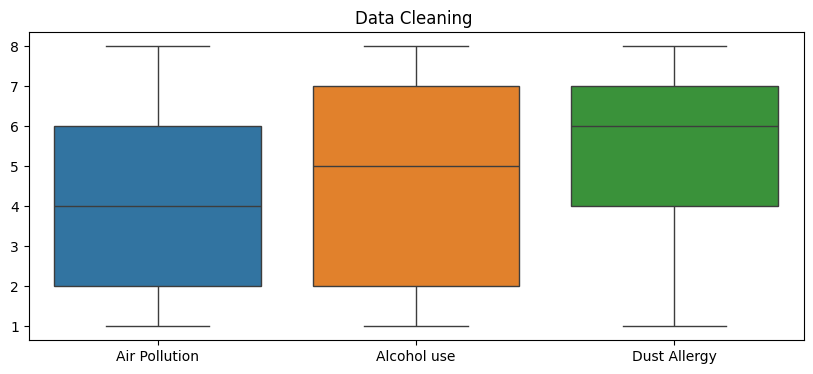

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df[['Air Pollution', 'Alcohol use', 'Dust Allergy']])
plt.title("Data Cleaning ")
plt.show()

# **Étape 5: Analyse de Corrélation**

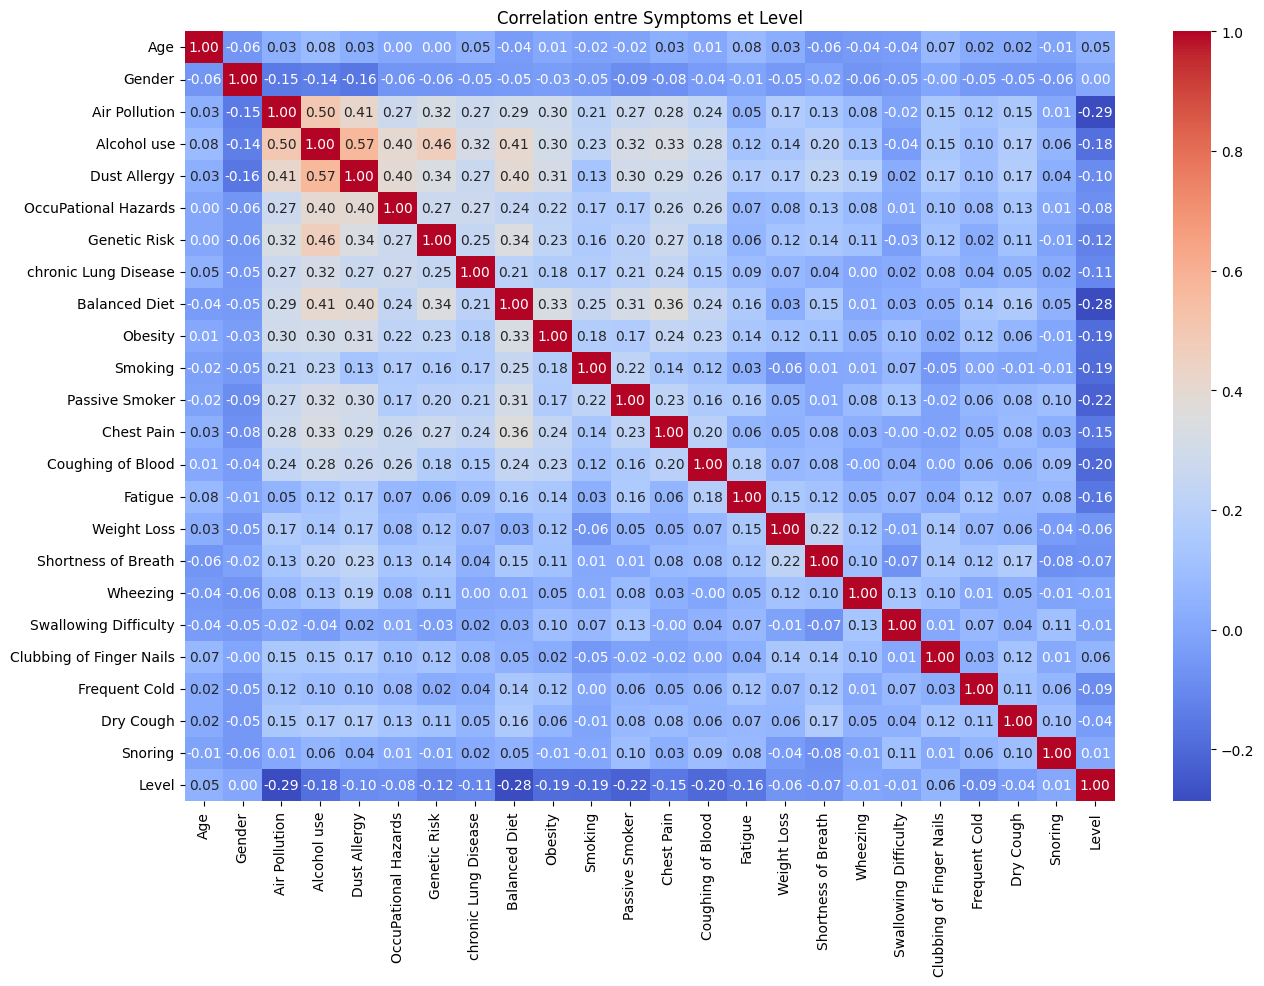

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation entre Symptoms et Level")
plt.show()

# **Étape 6: Préparation des Données**

In [ ]:
X = df.drop('Level', axis=1)
y = df['Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data Training: {X_train.shape[0]} patients")
print(f"Data Testing: {X_test.shape[0]} patients")

Data Training: 880 patients
Data Testing: 220 patients


# **Modèle 1: SVM (Support Vector Machine)**

In [ ]:
svm_model = SVC(kernel='linear', random_state=42)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%")

SVM Accuracy: 64.09%


# **Modèle 2: KNN (K-Nearest Neighbors)**

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%")

KNN Accuracy: 64.55%


# **Modèle 3: Logistic Regression (Régression Logistique)**

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")

Logistic Regression Accuracy: 66.36%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# **Modèle 4: Decision Tree (Arbre de Décision)**

Decision Tree Accuracy: 64.09%


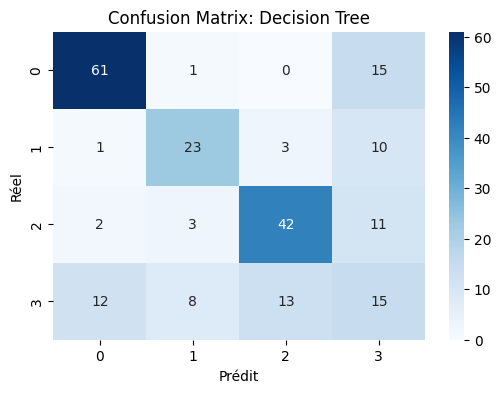

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt)*100:.2f}%")

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# **Modèle 5: Random Forest (Forêt Aléatoire)**

Random Forest Accuracy: 79.09%


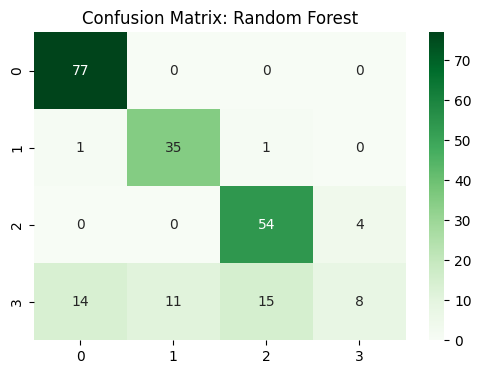

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Random Forest')
plt.show()